In [51]:
import tensorflow as tf
import keras
from keras.datasets import imdb
from keras.layers import (Layer,Embedding,Input,Dense, GlobalAveragePooling1D, Dropout, LayerNormalization, MultiHeadAttention)
from keras.models import Model

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

max_features = 10000 # vocabulary size
max_len = 250 # words per sample

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# pad all samples to same length
x_train = keras.utils.pad_sequences(x_train, maxlen=max_len, padding='post')
x_test = keras.utils.pad_sequences(x_test, maxlen=max_len, padding='post')

/home/jonih/anaconda3/envs/tf_2.21/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [52]:
word_to_index = imdb.get_word_index()
index_to_word = dict((value, key) for (key, value) in word_to_index.items())

example_review = " ".join(index_to_word.get(i-3, "?") for i in x_train[0])
print(example_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [53]:
from keras.layers import Layer, Embedding

class TokenAndPositionEmbedding(Layer):
    def __init__(self, seq_len, vocab_size, emb_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=emb_dim)
        self.pos_emb = Embedding(input_dim=seq_len, output_dim=emb_dim)

    def call(self, x_input):
        seq_len = keras.ops.shape(x_input)[-1]
        positions = keras.ops.arange(start=0, stop=seq_len, step=1)
        positions = self.pos_emb(positions)
        x_input = self.token_emb(x_input)
        return x_input + positions

In [54]:
embed_dim = 32
num_heads = 2 # number of attention heads
key_dim = embed_dim // num_heads # query/key dimension for one head
ff_dim    = 64

inputs = Input(shape=(max_len,))

# ── Embedding ──────────────────────────────────────────────────────────
x = TokenAndPositionEmbedding(max_len, max_features, embed_dim)(inputs)

# ── Lower block (figure): Multi-head attention  →  Add & Norm ──────────
attn_out = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)  # Q=K=V=x
x = LayerNormalization(epsilon=1e-6)(x + attn_out)  # residual + norm

# ── Upper block (figure): Feed forward  →  Add & Norm ─────────────────
ff_out = Dense(ff_dim, activation="relu")(x)
ff_out = Dense(embed_dim)(ff_out)  # must stay embed_dim!
x = LayerNormalization(epsilon=1e-6)(x + ff_out)  # residual + norm

# ── Classifier head ───────────────────────────────────────────────────
x = GlobalAveragePooling1D()(x)
x = Dropout(0.1)(x)
outputs = Dense(1, activation="sigmoid")(x)

transformer_model = Model(inputs=inputs, outputs=outputs)
transformer_model.compile(optimizer="adam",
                          loss="binary_crossentropy",
                          metrics=["accuracy"])

transformer_model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 250, 32)   │    328,000 │ input_layer_7[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 250, 32)   │      4,224 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 250, 32)   │          0 │ token_and_positi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 250, 32)   │         64 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 250, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 250, 32)   │      2,080 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 250, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 250, 32)   │         64 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 32)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │         33 │ dropout_13[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 336,577 (1.28 MB)

 Trainable params: 336,577 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
transformer_model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5


I0000 00:00:1776959762.820613    1209 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_191330__.45


696/704 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7063 - loss: 0.5364

I0000 00:00:1776959767.921240    1211 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_191330__.45


704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7074 - loss: 0.5349

I0000 00:00:1776959770.529745    1212 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_194604__.13
I0000 00:00:1776959771.495213    1212 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_194604__.13


704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8024 - loss: 0.4081 - val_accuracy: 0.8888 - val_loss: 0.2857
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9172 - loss: 0.2093 - val_accuracy: 0.8864 - val_loss: 0.2854
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9416 - loss: 0.1521 - val_accuracy: 0.8744 - val_loss: 0.3227
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9622 - loss: 0.1102 - val_accuracy: 0.8628 - val_loss: 0.3973
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9708 - loss: 0.0841 - val_accuracy: 0.8668 - val_loss: 0.4789


In [56]:
test_loss, test_acc = transformer_model.evaluate(x_test, y_test)
print(f"Test accuracy = {test_acc:.4f}")

773/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8565 - loss: 0.4945

I0000 00:00:1776959790.524801    1211 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_194604__.13


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8538 - loss: 0.5021
Test accuracy = 0.8538


In [57]:
# Create a model for outputting attention scores

inps = transformer_model.input
embedding_output = transformer_model.layers[1](inps)
att_output, att_scores = transformer_model.layers[2](embedding_output, embedding_output, return_attention_scores=True)
score_model = Model(inputs=inps, outputs=[att_output, att_scores])

In [58]:
sample_input = x_train[:1]  # a single training example
_, attention_scores_all = score_model.predict(sample_input)

# scores for a single attention head
head_index = 1
attention_scores = attention_scores_all[0][head_index]

# Verify the shape of attention scores
print(f"Attention scores, full shape: {attention_scores_all.shape}")
print(f"Attention scores, one head: {attention_scores.shape}")

I0000 00:00:1776959794.069059    1211 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_210988__.3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
Attention scores, full shape: (1, 2, 250, 250)
Attention scores, one head: (250, 250)


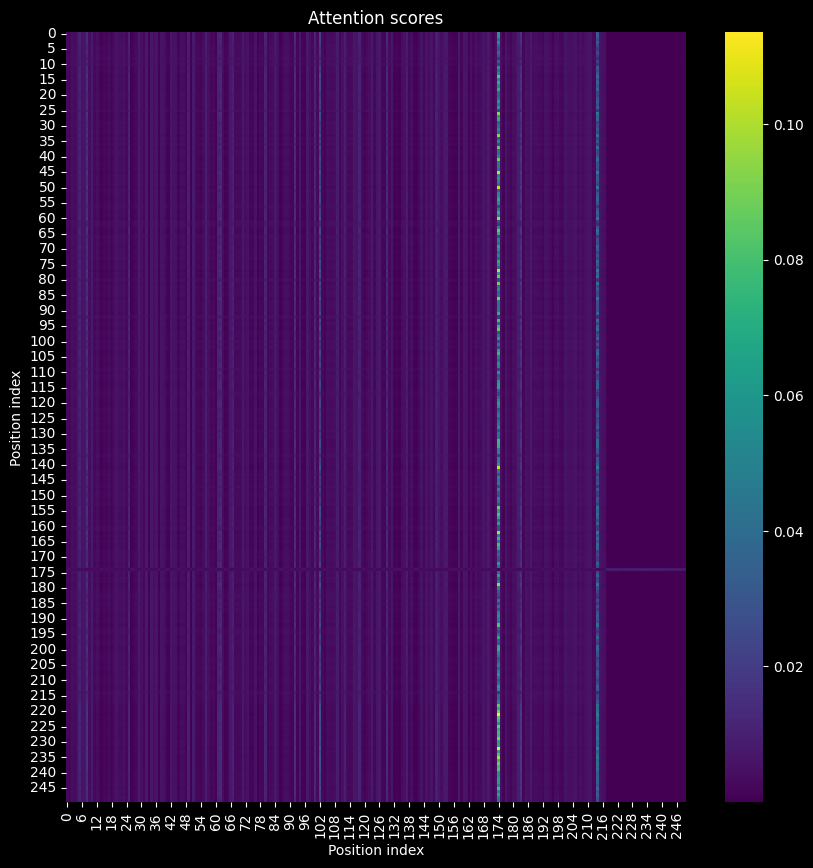

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.heatmap(attention_scores, cmap='viridis')
plt.title('Attention scores')
plt.xlabel('Position index')
plt.ylabel('Position index')
plt.show()

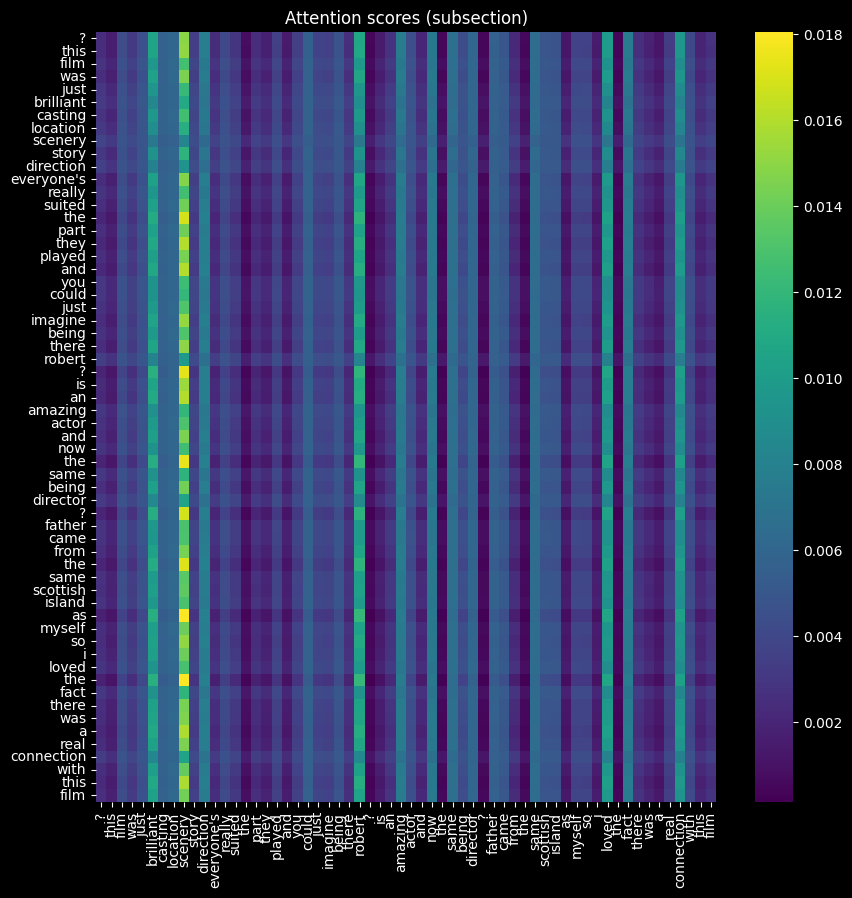

In [60]:
sub_length = 60  # Adjust the length of the subsection as needed
sub_scores = attention_scores[:sub_length, :sub_length]

# Plot the attention scores for the subsection
plt.figure(figsize=(10, 10))
sns.heatmap(sub_scores,
            cmap='viridis',
            xticklabels=[index_to_word.get(i-3, '?') for i in sample_input[0][:sub_length]],
            yticklabels=[index_to_word.get(i-3, '?') for i in sample_input[0][:sub_length]])
plt.title('Attention scores (subsection)')
plt.show()